<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_3_A_CSET_343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


In [9]:
#pima dataset - Tabular
!wget -O diabetes.csv https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

print("Dataset downloaded successfully!")

--2026-09-03 10:30:22--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  22.73K  --.-KB/s    in 0.002s  

2026-09-03 10:30:23 (10.3 MB/s) - ‘diabetes.csv’ saved [23278/23278]

Dataset downloaded successfully!


In [10]:
import pandas as pd

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    "diabetes.csv",
    names=columns
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [11]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
#basic info

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
# summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
#missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [15]:
#zero values
print("Zero values in each column:")
print((df == 0).sum())

Zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [16]:
# zero clinically implausible
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Columns where zero values will be treated as missing:")
print(medical_columns)

Columns where zero values will be treated as missing:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [17]:
# copy of original dataset

df_clean = df.copy()

# Replaced zero values with NaN in selected medical columns

df_clean[medical_columns] = (
    df_clean[medical_columns].replace(0, np.nan)
)

print("Missing values after clinical validation:")

print(df_clean.isnull().sum())

Missing values after clinical validation:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


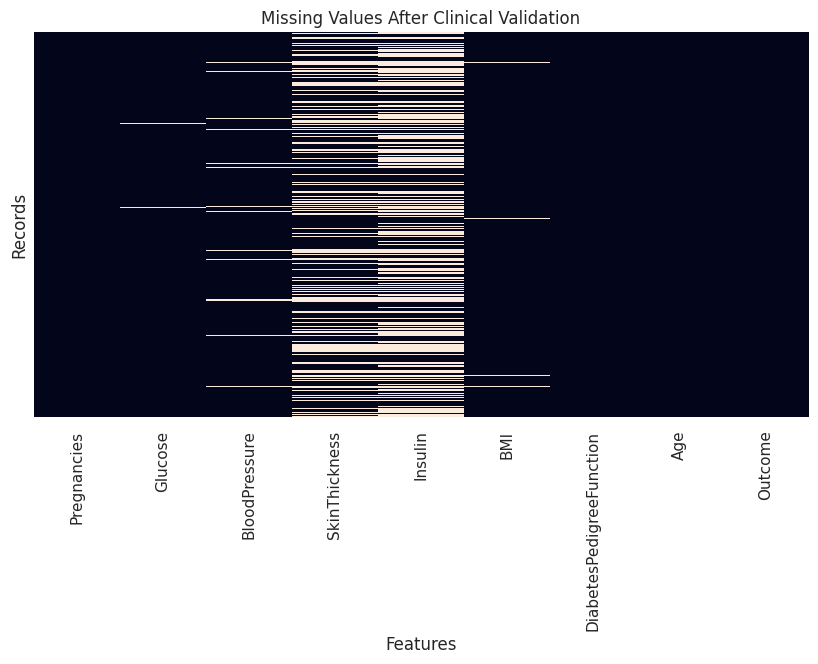

In [18]:
# Visualize missing values

plt.figure(figsize=(10, 5))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values After Clinical Validation")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

In [19]:
#percentage of missing values

missing_percentage = (
    df_clean.isnull().sum() / len(df_clean) * 100
).round(2)

print("Missing value percentage:")

print(missing_percentage)

Missing value percentage:
Pregnancies                  0.00
Glucose                      0.65
BloodPressure                4.56
SkinThickness               29.56
Insulin                     48.70
BMI                          1.43
DiabetesPedigreeFunction     0.00
Age                          0.00
Outcome                      0.00
dtype: float64


In [20]:
# Replace missing values with the median of each medical feature

for column in medical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

print("Missing values after median imputation:")

print(df_clean.isnull().sum())

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [21]:
#cleaned dataset

print("Cleaned Dataset:")

display(df_clean.head())

Cleaned Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [23]:
#duplicate records

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Remove duplicate records

df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:")

print(df_clean.shape)

Number of duplicate rows: 0
Dataset shape after removing duplicates:
(768, 9)


In [24]:
#reasonable ranges for clinical variables

clinical_ranges = {
    "Pregnancies": (0, 20),
    "Glucose": (40, 300),
    "BloodPressure": (30, 200),
    "SkinThickness": (1, 100),
    "Insulin": (1, 1000),
    "BMI": (10, 70),
    "DiabetesPedigreeFunction": (0, 3),
    "Age": (10, 120)
}

print("Potentially implausible values:\n")

for column, (lower, upper) in clinical_ranges.items():

    invalid = df_clean[
        (df_clean[column] < lower) |
        (df_clean[column] > upper)
    ]

    print(
        column,
        ":",
        len(invalid),
        "potentially implausible values"
    )

Potentially implausible values:

Pregnancies : 0 potentially implausible values
Glucose : 0 potentially implausible values
BloodPressure : 1 potentially implausible values
SkinThickness : 0 potentially implausible values
Insulin : 0 potentially implausible values
BMI : 0 potentially implausible values
DiabetesPedigreeFunction : 0 potentially implausible values
Age : 0 potentially implausible values


In [25]:
# Final overview after cleaning

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nColumn names:")
print(df_clean.columns.tolist())

print("\nFirst 5 records:")

display(df_clean.head())

Original dataset shape: (768, 9)
Cleaned dataset shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


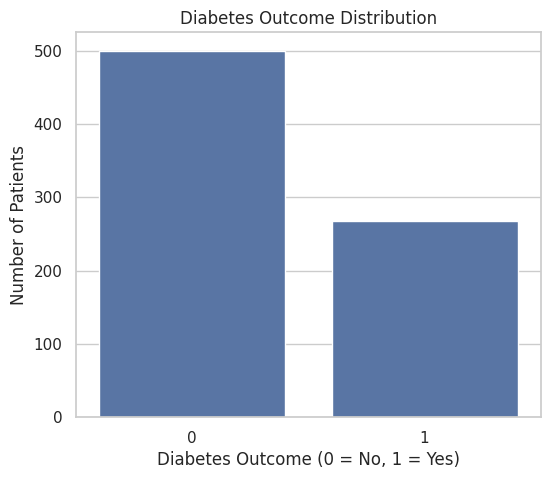

In [26]:
# Distribution of diabetes outcome

plt.figure(figsize=(6, 5))

sns.countplot(
    data=df_clean,
    x="Outcome"
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Diabetes Outcome (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

In [27]:
# Calculate percentage of diabetic and non-diabetic patients

outcome_percentage = (
    df_clean["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Diabetes Outcome Distribution (%):")

print(outcome_percentage)

Diabetes Outcome Distribution (%):
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


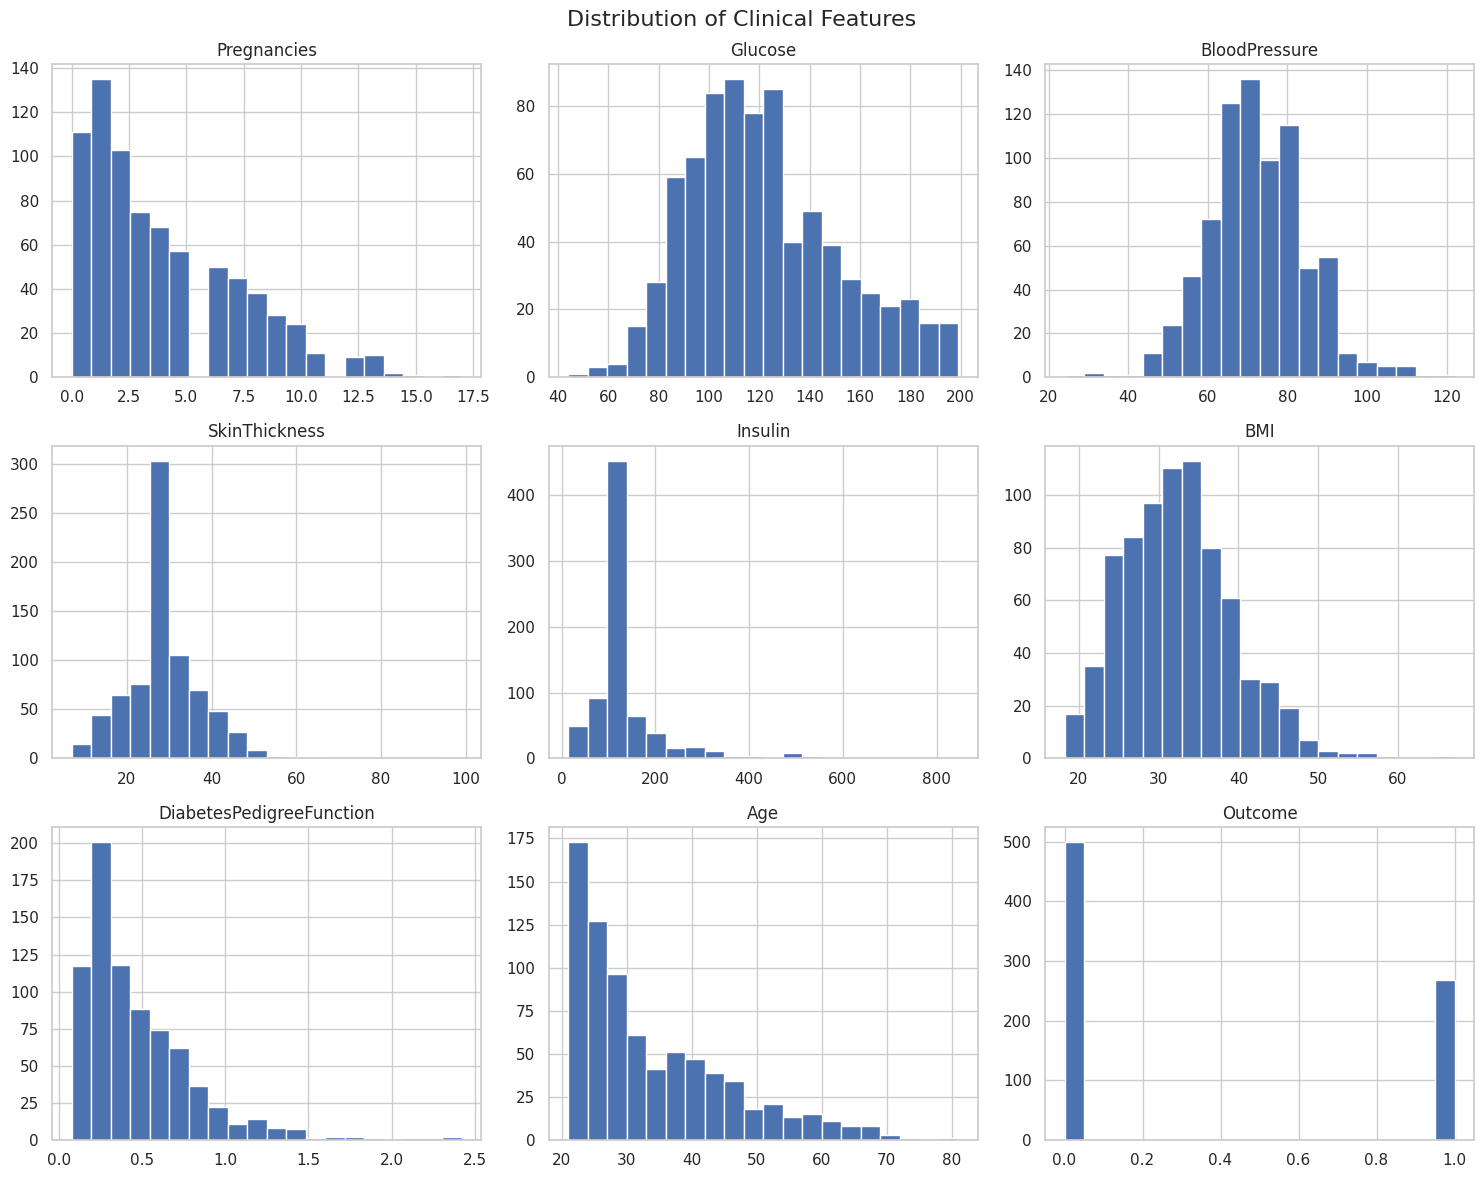

In [28]:
# Plot distributions of all numerical features

df_clean.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Clinical Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

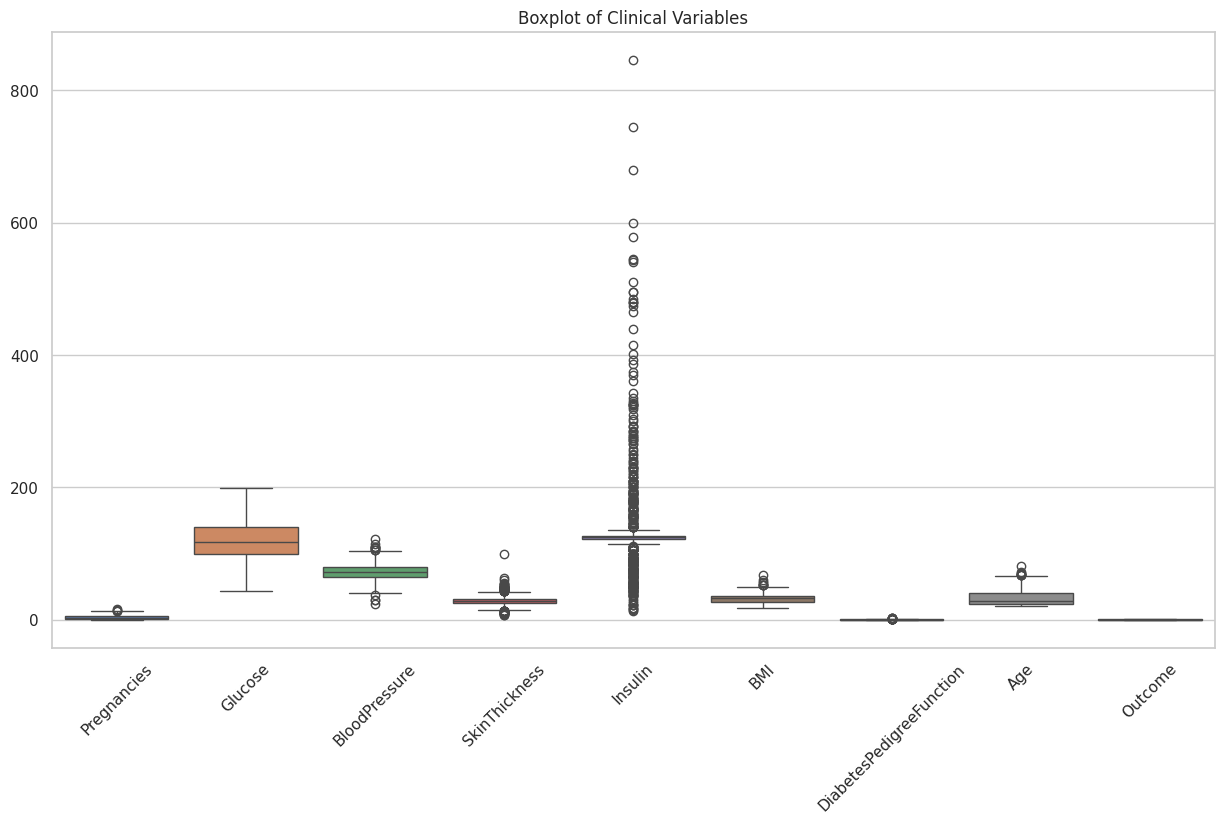

In [29]:
# Boxplots to identify potential outliers

plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df_clean
)

plt.xticks(rotation=45)

plt.title("Boxplot of Clinical Variables")

plt.show()

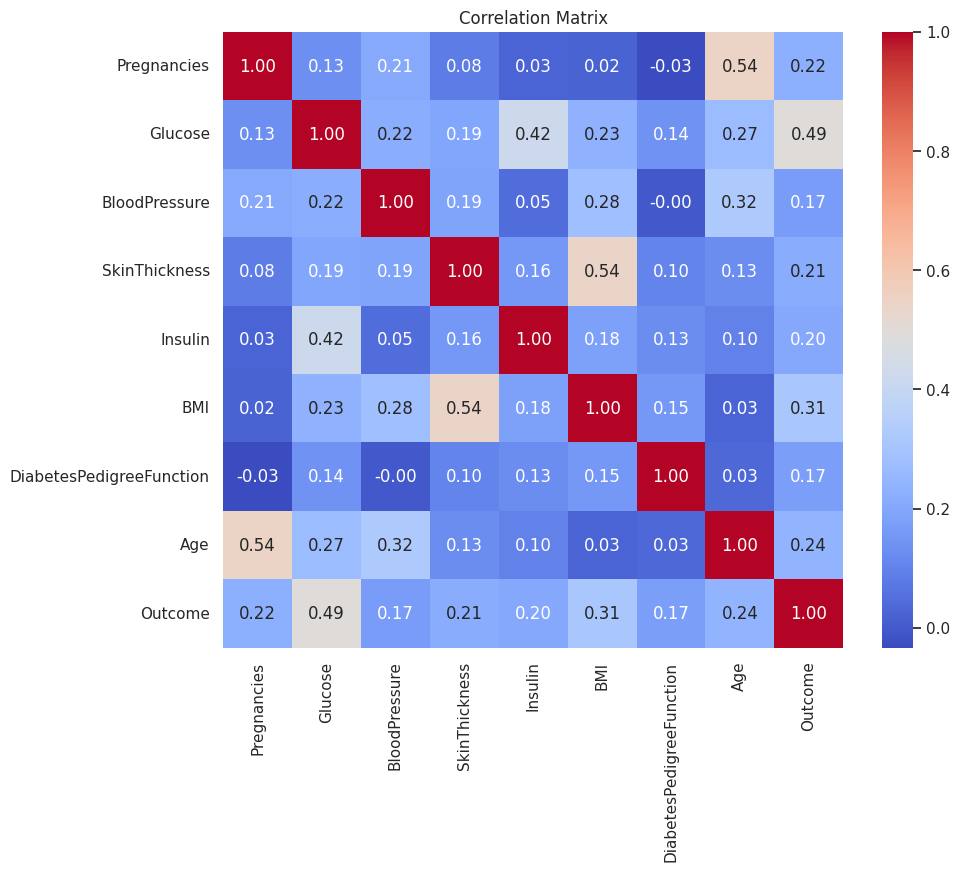

In [30]:
# Calculate correlation between numerical variables

correlation_matrix = df_clean.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

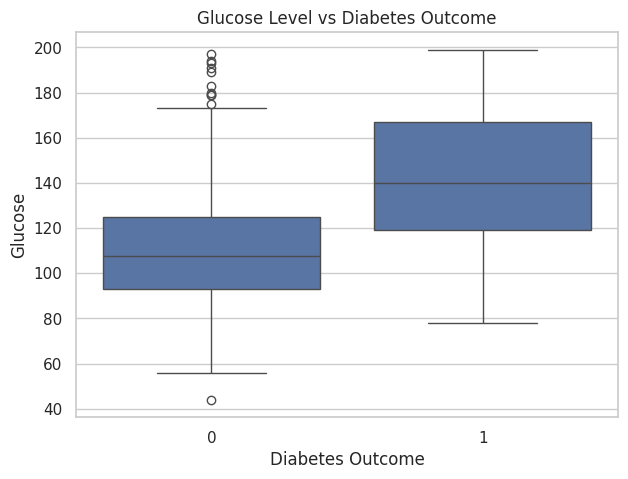

In [31]:
# Compare glucose levels between diabetes outcome groups

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="Glucose"
)

plt.title("Glucose Level vs Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Glucose")

plt.show()

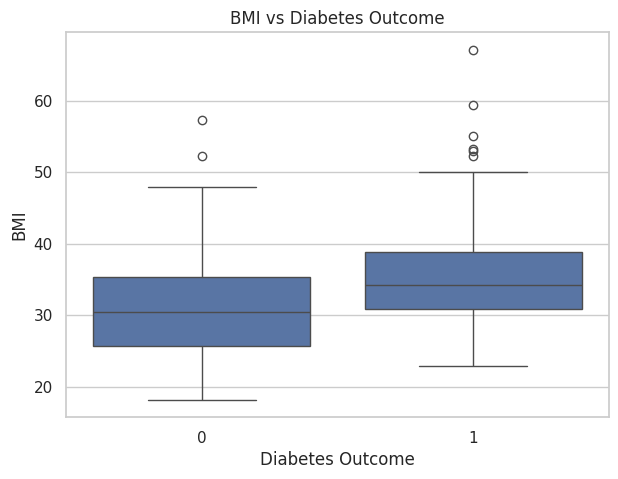

In [32]:
# BMI between diabetes outcome groups

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="BMI"
)

plt.title("BMI vs Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("BMI")

plt.show()

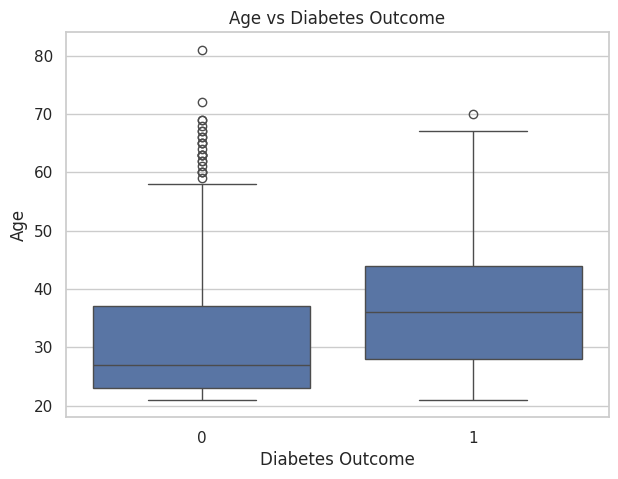

In [33]:
#age between diabetes outcome groups

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="Age"
)

plt.title("Age vs Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Age")

plt.show()

In [34]:
# Create BMI categories

def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"


df_clean["BMI_Category"] = df_clean["BMI"].apply(bmi_category)

display(
    df_clean[["BMI", "BMI_Category"]].head(10)
)

,BMI,BMI_Category
0,33.6,Obese
1,26.6,Overweight
2,23.3,Normal
3,28.1,Overweight
4,43.1,Obese
5,25.6,Overweight
6,31.0,Obese
7,35.3,Obese
8,30.5,Obese
9,32.3,Obese


In [35]:
# Create age groups

def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Middle-aged"
    else:
        return "Older"


df_clean["Age_Group"] = df_clean["Age"].apply(age_group)

display(
    df_clean[["Age", "Age_Group"]].head(10)
)

,Age,Age_Group
0,50,Older
1,31,Middle-aged
2,32,Middle-aged
3,21,Young
4,33,Middle-aged
5,30,Middle-aged
6,26,Young
7,29,Young
8,53,Older
9,54,Older


In [36]:
# Create glucose categories

def glucose_category(glucose):
    if glucose < 100:
        return "Normal"
    elif glucose < 126:
        return "Prediabetic"
    else:
        return "Diabetic-range"


df_clean["Glucose_Category"] = df_clean["Glucose"].apply(
    glucose_category
)

display(
    df_clean[["Glucose", "Glucose_Category"]].head(10)
)

,Glucose,Glucose_Category
0,148.0,Diabetic-range
1,85.0,Normal
2,183.0,Diabetic-range
3,89.0,Normal
4,137.0,Diabetic-range
5,116.0,Prediabetic
6,78.0,Normal
7,115.0,Prediabetic
8,197.0,Diabetic-range
9,125.0,Prediabetic


In [37]:
# Display the newly created features

display(
    df_clean[
        [
            "BMI",
            "BMI_Category",
            "Age",
            "Age_Group",
            "Glucose",
            "Glucose_Category"
        ]
    ].head(10)
)

,BMI,BMI_Category,Age,Age_Group,Glucose,Glucose_Category
0,33.6,Obese,50,Older,148.0,Diabetic-range
1,26.6,Overweight,31,Middle-aged,85.0,Normal
2,23.3,Normal,32,Middle-aged,183.0,Diabetic-range
3,28.1,Overweight,21,Young,89.0,Normal
4,43.1,Obese,33,Middle-aged,137.0,Diabetic-range
5,25.6,Overweight,30,Middle-aged,116.0,Prediabetic
6,31.0,Obese,26,Young,78.0,Normal
7,35.3,Obese,29,Young,115.0,Prediabetic
8,30.5,Obese,53,Older,197.0,Diabetic-range
9,32.3,Obese,54,Older,125.0,Prediabetic


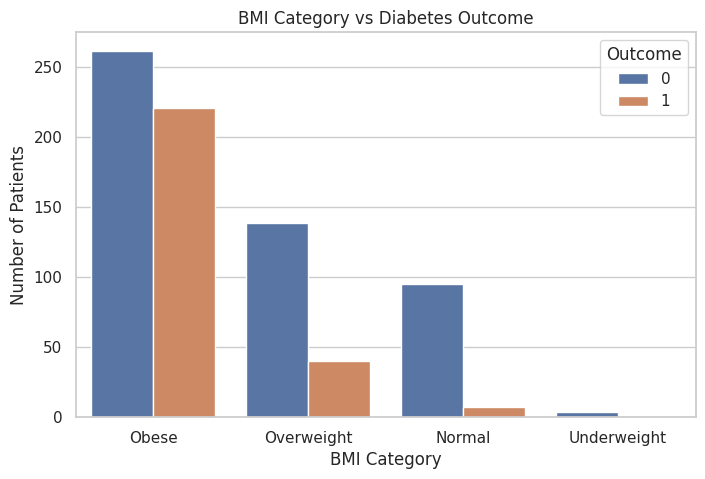

In [38]:
# Visualize BMI categories against diabetes outcome

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="BMI_Category",
    hue="Outcome"
)

plt.title("BMI Category vs Diabetes Outcome")
plt.xlabel("BMI Category")
plt.ylabel("Number of Patients")

plt.show()

In [39]:
# Create contingency table

bmi_outcome_table = pd.crosstab(
    df_clean["BMI_Category"],
    df_clean["Outcome"]
)

print("Contingency Table:")
display(bmi_outcome_table)

Contingency Table:


Outcome,0,1
BMI_Category,,
Normal,95,7
Obese,262,221
Overweight,139,40
Underweight,4,0


In [40]:
# Perform Chi-Square Test

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    bmi_outcome_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 74.9084804674606
p-value: 3.790718167139003e-16
Degrees of freedom: 3


In [41]:
# Interpret Chi-Square Test

alpha = 0.05

if p_value < alpha:
    print(
        "Reject H0: There is a statistically significant "
        "association between BMI category and diabetes outcome."
    )
else:
    print(
        "Fail to reject H0: There is no statistically significant "
        "association between BMI category and diabetes outcome."
    )

Reject H0: There is a statistically significant association between BMI category and diabetes outcome.


In [42]:
# Separate diabetic and non-diabetic patients

diabetic = df_clean[
    df_clean["Outcome"] == 1
]["Glucose"]

non_diabetic = df_clean[
    df_clean["Outcome"] == 0
]["Glucose"]

print("Mean glucose - Diabetic patients:",
      diabetic.mean())

print("Mean glucose - Non-diabetic patients:",
      non_diabetic.mean())

Mean glucose - Diabetic patients: 142.13059701492537
Mean glucose - Non-diabetic patients: 110.682


In [43]:
# Perform independent two-sample t-test

t_statistic, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 14.852653441079662
p-value: 3.5421485614431447e-41


In [44]:
# Interpret the hypothesis test

alpha = 0.05

if p_value < alpha:
    print(
        "Reject H0: There is a statistically significant "
        "difference in mean glucose levels between diabetic "
        "and non-diabetic patients."
    )
else:
    print(
        "Fail to reject H0: There is no statistically significant "
        "difference in mean glucose levels."
    )

Reject H0: There is a statistically significant difference in mean glucose levels between diabetic and non-diabetic patients.


In [45]:
# Create glucose groups based on BMI category

normal_bmi = df_clean[
    df_clean["BMI_Category"] == "Normal"
]["Glucose"]

overweight_bmi = df_clean[
    df_clean["BMI_Category"] == "Overweight"
]["Glucose"]

obese_bmi = df_clean[
    df_clean["BMI_Category"] == "Obese"
]["Glucose"]

print("Normal BMI patients:", len(normal_bmi))
print("Overweight patients:", len(overweight_bmi))
print("Obese patients:", len(obese_bmi))

Normal BMI patients: 102
Overweight patients: 179
Obese patients: 483


In [46]:
# Perform one-way ANOVA

f_statistic, p_value = f_oneway(
    normal_bmi,
    overweight_bmi,
    obese_bmi
)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 16.87820151767298
p-value: 6.726844350818829e-08


In [47]:
# Interpret ANOVA result

alpha = 0.05

if p_value < alpha:
    print(
        "Reject H0: Mean glucose levels differ significantly "
        "among BMI categories."
    )
else:
    print(
        "Fail to reject H0: There is no statistically significant "
        "difference in mean glucose levels among BMI categories."
    )

Reject H0: Mean glucose levels differ significantly among BMI categories.


In [48]:
# Select numerical features

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df_clean[features]

y = df_clean["Outcome"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (768, 8)
Target shape: (768,)


In [49]:
# Apply ANOVA F-test for feature selection

selector = SelectKBest(
    score_func=f_classif,
    k="all"
)

X_selected = selector.fit_transform(
    X,
    y
)

print("Feature selection completed.")

Feature selection completed.


In [50]:
# Create feature score table

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": selector.scores_,
    "P_Value": selector.pvalues_
})

feature_scores = feature_scores.sort_values(
    by="F_Score",
    ascending=False
)

display(feature_scores)

,Feature,F_Score,P_Value
1,Glucose,245.667855,3.128719e-48
5,BMI,82.629271,8.336903e-19
7,Age,46.140611,2.209975e-11
0,Pregnancies,39.670227,5.065127e-10
3,SkinThickness,37.078538,1.793958e-09
4,Insulin,33.190796,1.210026e-08
6,DiabetesPedigreeFunction,23.871300,1.254607e-06
2,BloodPressure,21.631580,3.890835e-06


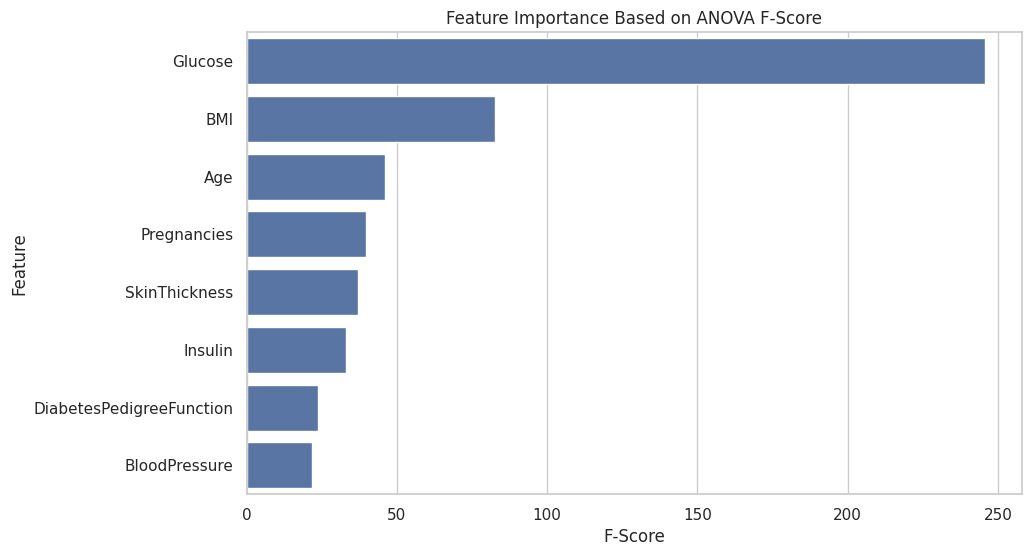

In [51]:
# Visualize feature importance using ANOVA F-score

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_scores,
    x="F_Score",
    y="Feature"
)

plt.title("Feature Importance Based on ANOVA F-Score")
plt.xlabel("F-Score")
plt.ylabel("Feature")

plt.show()

In [52]:
# Standardize numerical features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

display(X_scaled_df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


In [53]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (614, 8)
Testing features: (154, 8)
Training labels: (614,)
Testing labels: (154,)


In [54]:
# Final summary

print("========== FINAL DATASET SUMMARY ==========")

print("\nOriginal dataset shape:")
print(df.shape)

print("\nCleaned dataset shape:")
print(df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nClass distribution:")
print(df_clean["Outcome"].value_counts())

print("\nFeature Scores:")
display(feature_scores)

========== FINAL DATASET SUMMARY ==========

Original dataset shape:
(768, 9)

Cleaned dataset shape:
(768, 12)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Category                0
Age_Group                   0
Glucose_Category            0
dtype: int64

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Feature Scores:


,Feature,F_Score,P_Value
1,Glucose,245.667855,3.128719e-48
5,BMI,82.629271,8.336903e-19
7,Age,46.140611,2.209975e-11
0,Pregnancies,39.670227,5.065127e-10
3,SkinThickness,37.078538,1.793958e-09
4,Insulin,33.190796,1.210026e-08
6,DiabetesPedigreeFunction,23.871300,1.254607e-06
2,BloodPressure,21.631580,3.890835e-06


In [55]:
# Display final model-ready data

print("Training Features:")
display(X_train.head())

print("\nTesting Features:")
display(X_test.head())

print("\nTraining Labels:")
display(y_train.head())

print("\nTesting Labels:")
display(y_test.head())

Training Features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.844885,-1.040692,-0.859204,-1.947309,-1.131420,-0.764872,0.326546,-0.786286
711,0.342981,0.142800,0.464339,-0.239949,-1.374682,-0.415563,-0.099290,0.575118
373,-0.547919,-0.547570,-1.190090,1.239762,-0.540642,0.355829,-0.745596,-0.701198
46,-0.844885,0.800295,-1.355533,-0.012301,-0.181541,-0.401008,0.278225,-0.360847
682,-1.141852,-0.876318,-0.693761,1.125938,-0.413219,1.767621,-0.319759,-0.956462



Testing Features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,0.936914,1.227667,-0.693761,-0.012301,-0.181541,-0.735763,-0.537208,0.575118
672,1.827813,-1.763937,2.780539,-0.695245,-1.061917,0.443156,-0.564389,1.170732
700,-0.547919,0.011301,0.298896,-0.239949,0.687250,0.501374,0.033595,-0.616111
630,0.936914,-0.251697,-0.693761,-0.012301,-0.181541,-0.735763,0.785604,0.064591
81,-0.547919,-1.566688,-0.031990,-0.012301,-0.181541,-0.022590,-1.117070,-0.956462



Training Labels:


,Outcome
353,0
711,0
373,0
46,0
682,0



Testing Labels:


,Outcome
44,0
672,0
700,0
630,1
81,0
